## Time series analysis of lateral velocity:
This notebook analyses the variation in lateral velocity, $`u_y`$, over time to detect von Kármán vortex shedding and how surpression of this may contribute to reduced drag coefficient. Analysis was conducted with free stream velocity of $`0.1`$ m s $`^{-1}`$.

`time_series.csv` and `FFT.csv` files for each taxon were created manually in paraview (see `time_series_analysis.pvsm` in `[taxon]/velocity/v0.1/postProcessing/`).

In [4]:
#import libraries:
import numpy as np
import paraview
import glob
import os
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.signal import welch
import csv
import gc
import parameters as par
import functions as func

### Edrioasteroids

Length of velocity data:  322
length of flow_through_time:  64.5
Time values sampled:  129  to  645
Peak occurs at St =  0.001953125


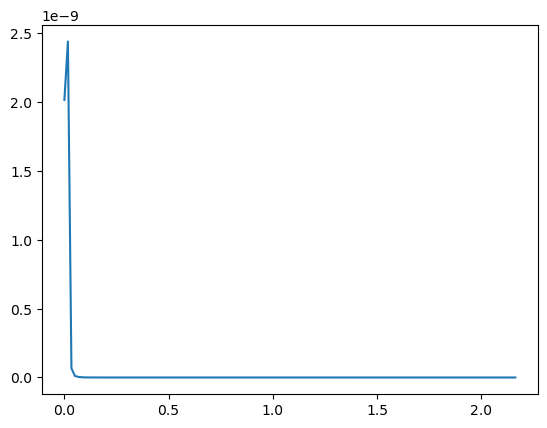

In [5]:
stromat_100 = func.calc_FFT(taxon = par.Stromatocystites.name, 
                            file = 'probe_0.15_0.06_0.015.csv', 
                            L = par.Stromatocystites.L, 
                            Re = 100, 
                            flow_through_time = 129, 
                            endTime = 645, 
                            writeInterval = 2, 
                            nu = par.Env1.nu)
fig = plt.figure()
plt.plot(stromat_100['strouhal'], stromat_100['psd'], label=par.Stromatocystites.label)
plt.show()

Length of velocity data:  258
length of flow_through_time:  51.6
Time values sampled:  25.8  to  129.3
Peak occurs at St =  0.01932367149758454


/mnt/apps/users/jmcdermo/conda/lib/python3.12/site-packages/scipy/signal/_spectral_py.py:790: UserWarning: nperseg = 256 is greater than input length  = 207, using nperseg = 207
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


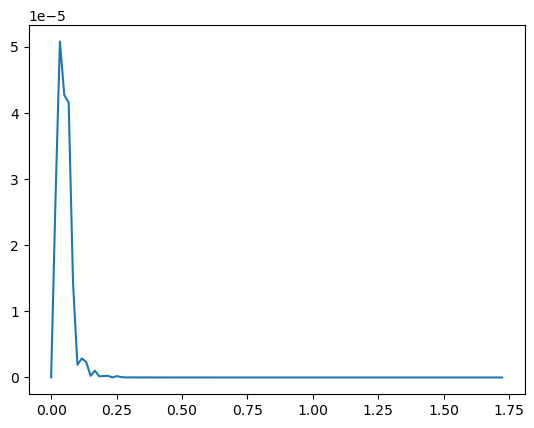

In [6]:
stromat_500 = func.calc_FFT(taxon = par.Stromatocystites.name, 
                            file = 'probe_0.15_0.0_0.015.csv', 
                            L = par.Stromatocystites.L, 
                            Re = 500, 
                            flow_through_time = 25.8, 
                            endTime = 129, 
                            writeInterval = 0.5, 
                            nu = par.Env1.nu)
fig = plt.figure()
plt.plot(stromat_500['strouhal'], stromat_500['psd'], label=par.Stromatocystites.label)
plt.show()

Length of velocity data:  325
length of flow_through_time:  64.5
Time values sampled:  12.9  to  65.09999999999982
Peak occurs at St =  0.1953125


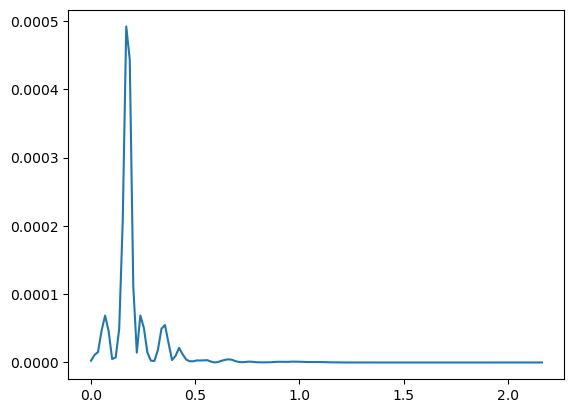

In [7]:
stromat_1000 = func.calc_FFT(taxon = par.Stromatocystites.name, 
                            file = 'probe_0.15_0.0_0.015.csv', 
                            L = par.Stromatocystites.L, 
                            Re = 1000, 
                            flow_through_time = 12.9, 
                            endTime = 65, 
                            writeInterval = 0.2, 
                            nu = par.Env1.nu)
fig = plt.figure()
plt.plot(stromat_1000['strouhal'], stromat_1000['psd'], label=par.Stromatocystites.label)
plt.show()

Length of velocity data:  260
length of flow_through_time:  51.6
Time values sampled:  2.58  to  13.029999999999964
Peak occurs at St =  1.1483253588516744
12
0.19874861980125136


/mnt/apps/users/jmcdermo/conda/lib/python3.12/site-packages/scipy/signal/_spectral_py.py:790: UserWarning: nperseg = 256 is greater than input length  = 209, using nperseg = 209
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


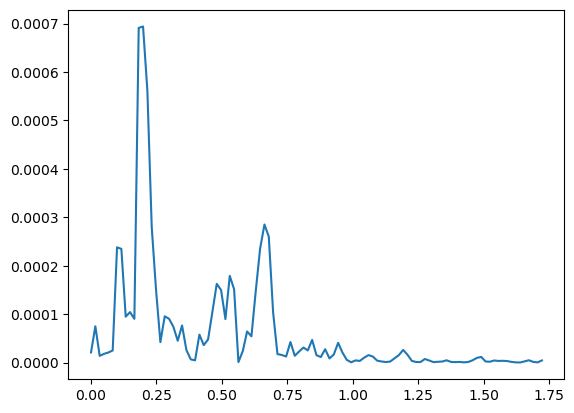

In [8]:
stromat_5000 = func.calc_FFT(taxon = par.Stromatocystites.name, 
                            file = 'probe_0.15_0.0_0.015.csv', 
                            L = par.Stromatocystites.L, 
                            Re = 5000, 
                            flow_through_time = 2.58, 
                            endTime = 13, 
                            writeInterval = 0.05, 
                            nu = par.Env1.nu)
print(np.argmax(stromat_5000['psd']))
print(stromat_5000['strouhal'][12])
fig = plt.figure()
plt.plot(stromat_5000['strouhal'], stromat_5000['psd'], label=par.Stromatocystites.label)
plt.show()

Length of velocity data:  325
length of flow_through_time:  64.5
Time values sampled:  1.29  to  6.510000000000004
Peak occurs at St =  2.9296875
15
0.2535306490384615


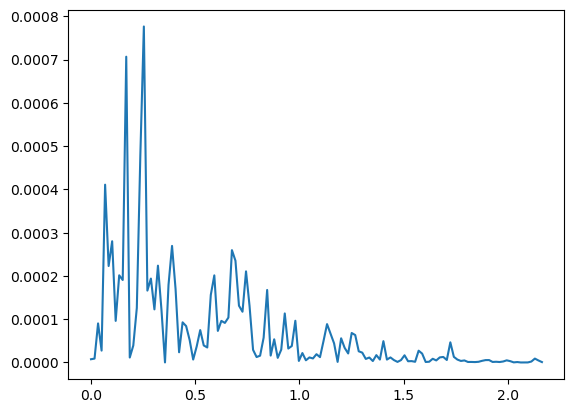

In [9]:
stromat_10000 = func.calc_FFT(taxon = par.Stromatocystites.name, 
                            file = 'probe_0.15_0.0_0.015.csv', 
                            L = par.Stromatocystites.L, 
                            Re = 10000, 
                            flow_through_time = 1.29, 
                            endTime = 6.5, 
                            writeInterval = 0.02, 
                            nu = par.Env1.nu)
print(np.argmax(stromat_10000['psd']))
print(stromat_10000['strouhal'][np.argmax(stromat_10000['psd'])])
fig = plt.figure()
plt.plot(stromat_10000['strouhal'], stromat_10000['psd'], label=par.Stromatocystites.label)
plt.show()

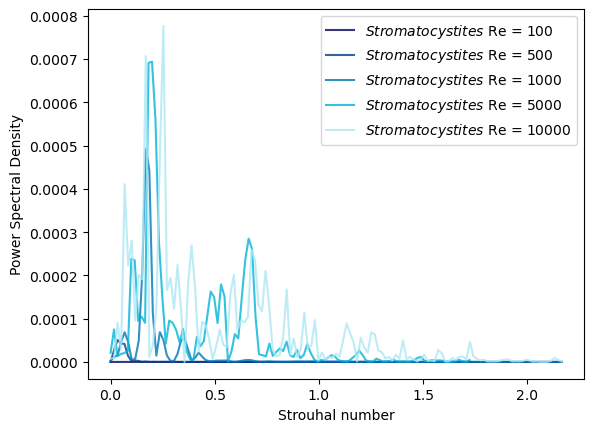

In [18]:
fig, ax = plt.subplots()
ax.plot(stromat_100['strouhal'], stromat_100['psd'], label=par.Stromatocystites.label + ' Re = 100', color='#03045e',alpha=0.8)
ax.plot(stromat_500['strouhal'], stromat_500['psd'], label=par.Stromatocystites.label + ' Re = 500', color='#023e8a',alpha=0.8)
ax.plot(stromat_1000['strouhal'], stromat_1000['psd'], label=par.Stromatocystites.label + ' Re = 1000', color='#0077b6',alpha=0.8)
ax.plot(stromat_5000['strouhal'], stromat_5000['psd'], label=par.Stromatocystites.label + ' Re = 5000', color='#00b4d8',alpha=0.8)
ax.plot(stromat_10000['strouhal'], stromat_10000['psd'], label=par.Stromatocystites.label + ' Re = 10000', color='#ade8f4',alpha=0.8)
ax.set_xlabel('Strouhal number')
ax.set_ylabel('Power Spectral Density')
ax.legend()
plt.show()
